In [1]:
from figgie_gym.envs.common import SUITS

In [2]:
import pandas as pd

full_df = pd.read_parquet("/Users/yawerijaz/mlflow_dir/mlartifacts/1/573612bb0a2843cd853559ee41c8093e/artifacts/predictions")


In [3]:
full_df.shape[0] / 10000 * 100

20500.0

In [4]:
df = full_df.tail(20500*20)
df["hidden.game_info.goal_suit"]
df["prob_combinatoric_Club"]
is_model_correct = (df[[f"prob_model_{s}" for s in SUITS]].idxmax(axis=1).str.removeprefix("prob_model_") == df["hidden.game_info.goal_suit"])
is_combinatoric_correct = (df[[f"prob_combinatoric_{s}" for s in SUITS]].idxmax(axis=1).str.removeprefix("prob_combinatoric_") == df["hidden.game_info.goal_suit"])

In [5]:
df.assign(
    is_model_correct=is_model_correct,
    is_combinatoric_correct=is_combinatoric_correct,
).pivot_table(
    # index="raw.step",
    index="hidden.game_info.num_cardcounter_agents",
    values=["is_model_correct","is_combinatoric_correct"],
)

,is_combinatoric_correct,is_model_correct
hidden.game_info.num_cardcounter_agents,,
0,0.643819,0.615263
1,0.621791,0.638858
2,0.667907,0.692848
3,0.627086,0.691294
4,0.589659,0.701241
5,0.474986,0.727855


<Axes: title={'center': 'when 5 out of 5 agents are combinatoric-based'}, xlabel='raw.step'>

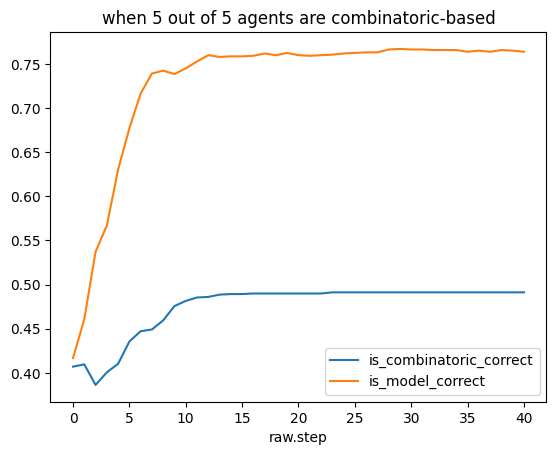

In [12]:
df.assign(
    is_model_correct=is_model_correct,
    is_combinatoric_correct=is_combinatoric_correct,
)[df["hidden.game_info.num_cardcounter_agents"]==5].pivot_table(
     index="raw.step",
    #index="hidden.game_info.num_cardcounter_agents",
    values=["is_model_correct","is_combinatoric_correct"],
).plot(title='when 5 out of 5 agents are combinatoric-based')

In [17]:
from sklearn.metrics import log_loss

In [19]:
df[[f"prob_model_{s}" for s in SUITS]].assign(goal_suit=df["hidden.game_info.goal_suit_code"], step=df["raw.step"]).groupby('step').agg(
    lambda d: print(d) and log_loss(d['goal_suit'], d[[f"prob_model_{s}" for s in SUITS]])
)

1640000    0.080190
1640001    0.231305
1640002    0.407797
1640003    0.315006
1640004    0.325769
             ...   
2049795    0.211010
2049796    0.069771
2049797    0.212311
2049798    0.217257
2049799    0.249152
Name: prob_model_Spade, Length: 10000, dtype: float32
1640005    0.037391
1640006    0.137669
1640007    0.404681
1640008    0.224521
1640009    0.355057
             ...   
2049800    0.134094
2049801    0.030912
2049802    0.120280
2049803    0.139977
2049804    0.119834
Name: prob_model_Spade, Length: 10000, dtype: float32
1640010    0.034078
1640011    0.051874
1640012    0.450261
1640013    0.230314
1640014    0.352585
             ...   
2049805    0.074081
2049806    0.059169
2049807    0.092735
2049808    0.142699
2049809    0.130583
Name: prob_model_Spade, Length: 10000, dtype: float32
1640015    0.053474
1640016    0.042712
1640017    0.653262
1640018    0.335768
1640019    0.379609
             ...   
2049810    0.028064
2049811    0.011950
2049812    0.08699

,prob_model_Spade,prob_model_Club,prob_model_Heart,prob_model_Diamond,goal_suit
step,,,,,
0,None,None,None,None,None
1,None,None,None,None,None
2,None,None,None,None,None
3,None,None,None,None,None
4,None,None,None,None,None
5,None,None,None,None,None
6,None,None,None,None,None
7,None,None,None,None,None
8,None,None,None,None,None
